# Прогнозирование болезней

Действия над числами

In [4]:
x = 2 + 3
y = 2 * 3
print(f"2 + 3 = {x}")
print(f"2 * 3 = {y}")

2 + 3 = 5
2 * 3 = 6


In [5]:
print(x < y)

True


In [1]:
import pandas as pd

In [2]:
import tensorflow as tf

I0000 00:00:1791545151.755113    8237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791545151.818210    8237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791545153.664466    8237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
from tensorflow import keras

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
keras.utils.set_random_seed(42)

In [7]:
df = pd.read_csv("heart.csv")

In [8]:
df.shape

(303, 14)

In [9]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0


In [10]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

In [11]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

In [12]:
df1 = pd.get_dummies(df, columns = categorical_variables, dtype=int)

In [13]:
df1.head(3)

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1


In [14]:
test_df = df1.sample(frac=0.2, random_state=42)
train_df = df1.drop(test_df.index)

In [15]:
train_df.shape

(242, 30)

In [16]:
test_df.shape

(61, 30)

In [17]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [18]:
means

age          54.268595
trestbps    131.995868
chol        246.512397
thalach     149.805785
oldpeak       1.032645
slope         1.590909
dtype: float64

In [19]:
train_df[numerics]= (train_df[numerics] - means)/sd
test_df[numerics]= (test_df[numerics] - means)/sd

In [20]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [21]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [22]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [23]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [24]:
train_y = train[:, 6]
test_y = test[:, 6]

In [25]:
train_y.shape, test_y.shape

((242,), (61,))

In [47]:
num_columns = train_X.shape[1]

# define the input layer
input = keras.Input(shape=(num_columns,))

# feed the input vector to the hidden layer
# optional: you can give names to each layer to help
# keep track. This doesn't affect the training etc.

h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)

# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)

# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

In [31]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
(29 + 1)* 16 + (16 + 1) * 1

497

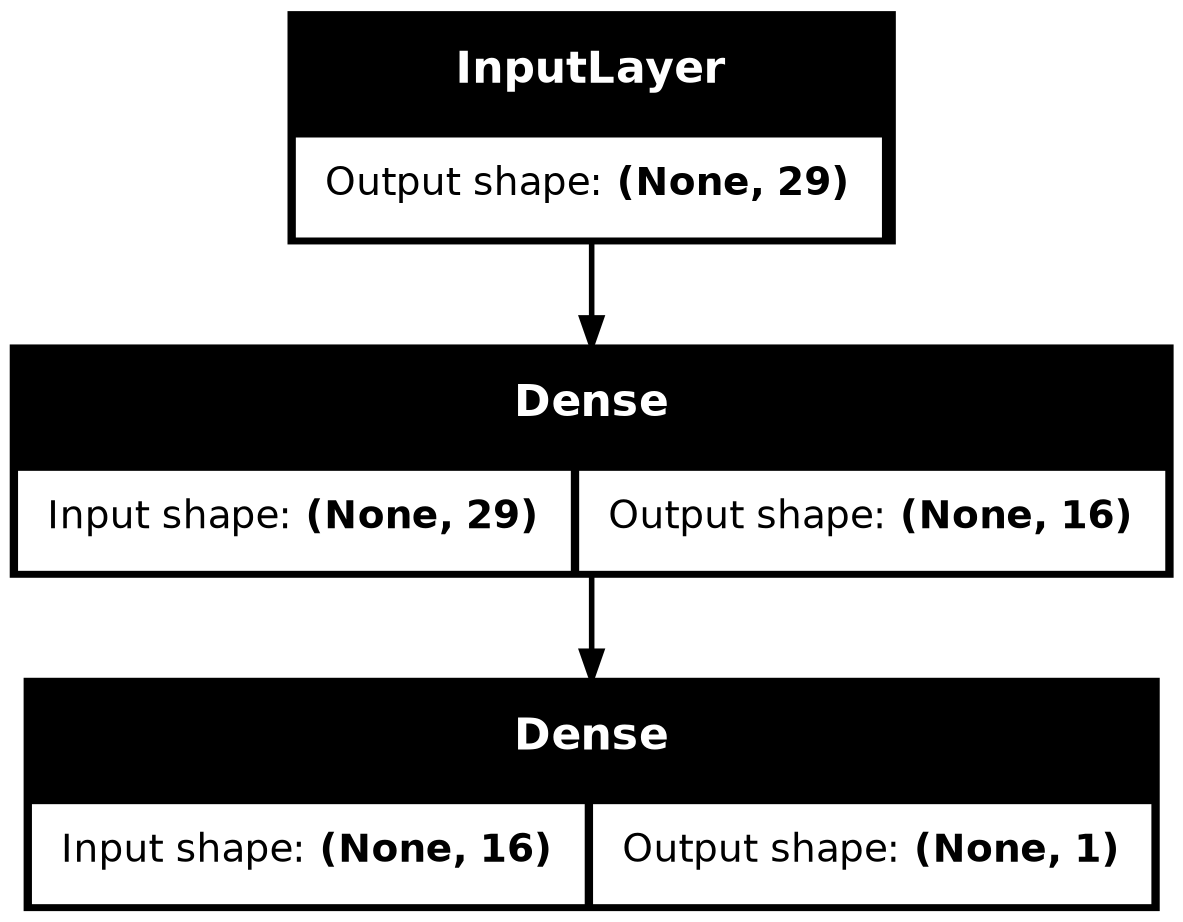

In [49]:
keras.utils.plot_model(model, show_shapes=True)

In [50]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [51]:
history = model.fit(train_X,              # the array with the input X columns
                    train_y,              # the array with the output y column
                    epochs=300,           # number of epochs to run
                    batch_size=32,        # number of samples (ie data points) per batch
                    verbose=1,            # verbosity during training
                    validation_split=0.2) # use 20% of the data for validation

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2642 - loss: 1.0170 - val_accuracy: 0.3673 - val_loss: 0.8922
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2694 - loss: 0.9615 - val_accuracy: 0.3265 - val_loss: 0.8573
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2850 - loss: 0.9160 - val_accuracy: 0.3469 - val_loss: 0.8269
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2850 - loss: 0.8760 - val_accuracy: 0.3673 - val_loss: 0.7998
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3109 - loss: 0.8409 - val_accuracy: 0.4082 - val_loss: 0.7758
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3420 - loss: 0.8099 - val_accuracy: 0.4490 - val_loss: 0.7556
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3679 - loss: 0.7824 - val_accuracy: 0.4898 - val_loss: 0.7375
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4145 - loss: 0.7575 - val_accuracy: 0.5102 - val_loss: 0.721

In [52]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

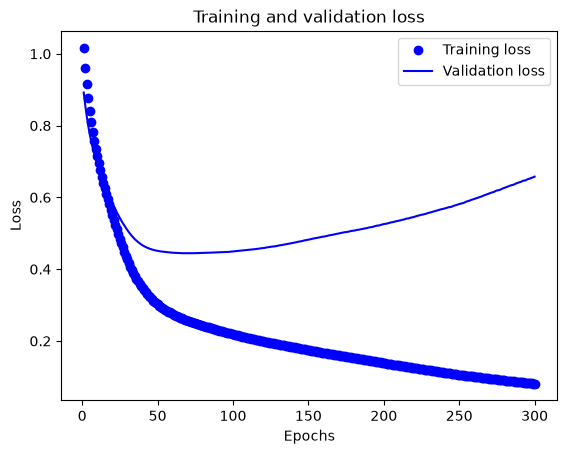

In [53]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

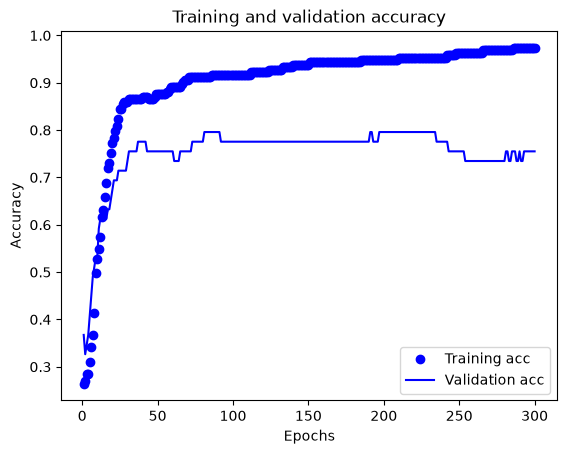

In [54]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [55]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8197 - loss: 0.5428


[0.5428091287612915, 0.8196721076965332]